In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Q1

In [2]:
data = {"salary": [1.7, 2.4, 2.3, 3.1, 3.7, 4.2,
               4.4, 6.1, 5.4, 5.7, 6.4, 6.2],

    "experience": [1.2, 1.5, 1.9, 2.2, 2.4, 2.5,
                   2.8, 3.1, 3.3, 3.7, 4.2, 4.4]}


df=pd.DataFrame(data)
df.to_csv("salary_experience.csv", index=False)

In [3]:
x=df["experience"].values
y=df["salary"].values

## a.

In [6]:
b=1.1
betas=[0.1, 1.5, 0.8]

mse_values=[]

for beta in betas:
    
    y_pred=beta*x+b
    mse=np.mean((y-y_pred)**2)
    
    mse_values.append(mse)
    
    print(f"Beta = {beta}, MSE = {mse}")

Beta = 0.1, MSE = 10.81115
Beta = 1.5, MSE = 1.1404166666666662
Beta = 0.8, MSE = 1.762599999999999


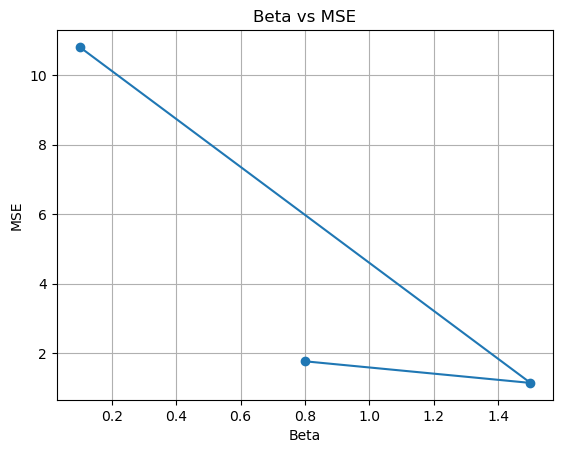

In [7]:
plt.figure()

plt.plot(betas, mse_values, marker="o")

plt.xlabel("Beta")
plt.ylabel("MSE")
plt.title("Beta vs MSE")
plt.grid()
plt.show()

## b.

In [8]:
b=1.1

beta_range=np.arange(0, 1.51, 0.01)

mse_beta=[]

for beta in beta_range:
    
    y_pred=beta*x+b
    
    mse=np.mean((y-y_pred)**2)
    
    mse_beta.append(mse)


min_index=np.argmin(mse_beta)

print("Best Beta =", round(beta_range[min_index], 4))
print("Minimum MSE =", round(mse_beta[min_index], 4))

Best Beta = 1.2
Minimum MSE = 0.3753


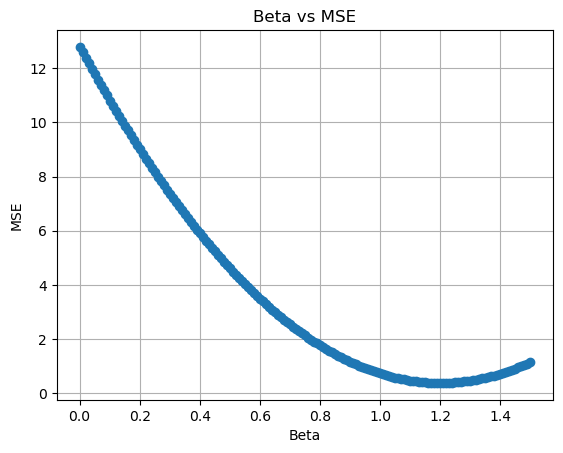

In [9]:
plt.figure()

plt.plot(beta_range, mse_beta, marker="o")

plt.xlabel("Beta")
plt.ylabel("MSE")
plt.title("Beta vs MSE")
plt.grid()
plt.show()

## c.


Intercept = -1
Best Beta = 1.5
Minimum MSE = 1.5604

Intercept = 0
Best Beta = 1.5
Minimum MSE = 0.2604

Intercept = 0.5
Best Beta = 1.39
Minimum MSE = 0.2654

Intercept = 1.1
Best Beta = 1.2
Minimum MSE = 0.3753

Intercept = 1.5
Best Beta = 1.07
Minimum MSE = 0.4926

Intercept = 2
Best Beta = 0.91
Minimum MSE = 0.6886


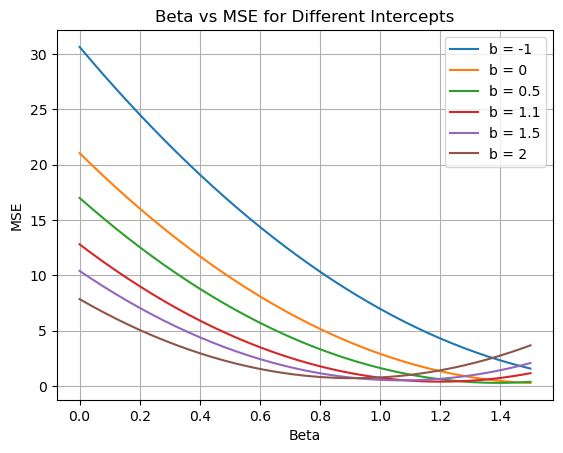

In [10]:
intercepts=[-1, 0, 0.5, 1.1, 1.5, 2]
plt.figure()

for b in intercepts:
    mse_values=[]
    for beta in beta_range:

        y_pred=beta*x+b

        mse=np.mean((y-y_pred)**2)
        mse_values.append(mse)


    min_index=np.argmin(mse_values)

    print("\nIntercept =", b)
    print("Best Beta =", round(beta_range[min_index], 4))
    print("Minimum MSE =", round(mse_values[min_index], 4))


    plt.plot(
        beta_range,
        mse_values,
        label=f"b = {b}"
    )


plt.xlabel("Beta")
plt.ylabel("MSE")
plt.title("Beta vs MSE for Different Intercepts")
plt.legend()
plt.grid()
plt.show()

# Q2.

In [11]:
n=len(x)
alpha=0.01

B0 = 0
B1 = 0

iterations=[]
errors=[]
log_errors=[]
beta_values=[]

iteration=0

for epoch in range(5):

    for i in range(n):

        y_pred=B0+B1*x[i]

        error=y_pred-y[i]

        B0=B0-alpha*error
        B1=B1-alpha*error*x[i]
        
        mse=error**2

        iteration=iteration+1

        iterations.append(iteration)
        errors.append(mse)
        log_errors.append(np.log(mse))
        beta_values.append(B1)

print("B0 =", round(B0, 4))
print("B1 =", round(B1, 4))
print("Error (MSE) =", round(errors[-1], 4))

B0 = 0.475
B1 = 1.3938
Error (MSE) = 0.2622


## a.

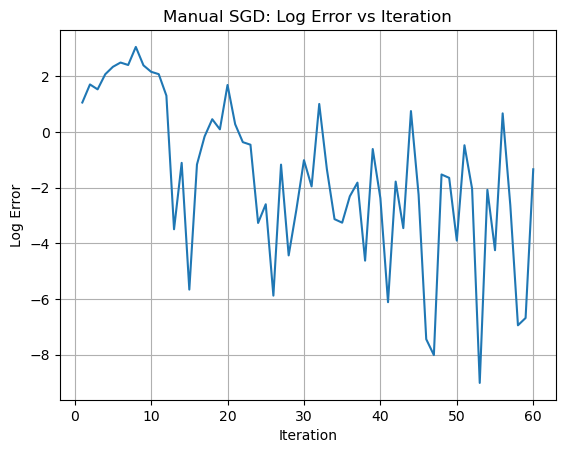

In [12]:
plt.figure()

plt.plot(iterations, log_errors)

plt.xlabel("Iteration")
plt.ylabel("Log Error")
plt.title("Manual SGD: Log Error vs Iteration")

plt.grid()
plt.show()

## d.

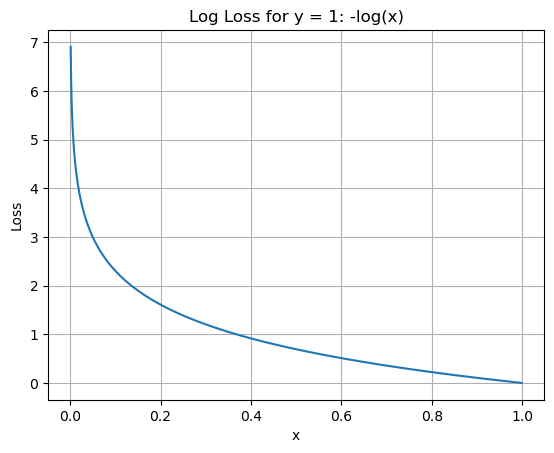

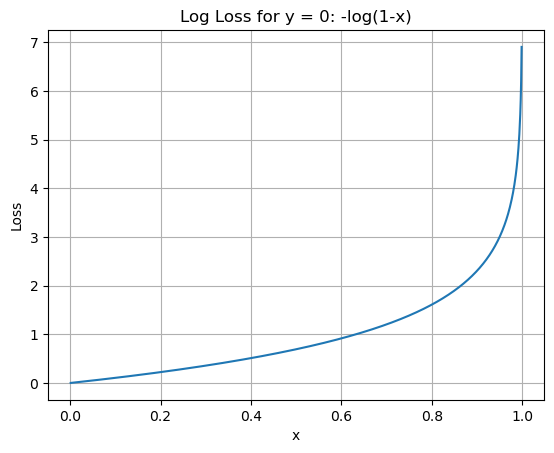

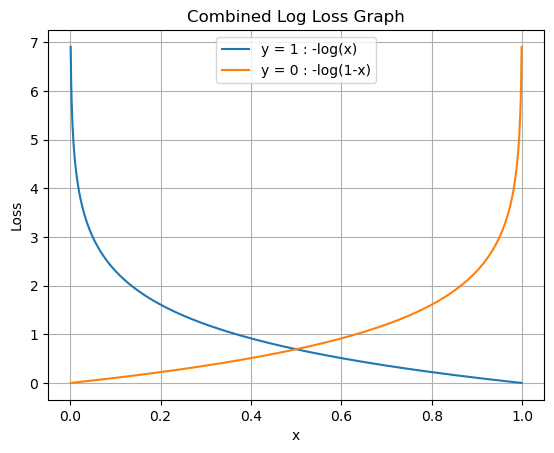

In [15]:
x = np.linspace(0.001, 0.999, 1000)

loss_y1 = -np.log(x)
plt.figure()
plt.plot(x, loss_y1)

plt.xlabel("x")
plt.ylabel("Loss")
plt.title("Log Loss for y = 1: -log(x)")

plt.grid()
plt.show()



loss_y0 = -np.log(1 - x)
plt.figure()
plt.plot(x, loss_y0)

plt.xlabel("x")
plt.ylabel("Loss")
plt.title("Log Loss for y = 0: -log(1-x)")

plt.grid()
plt.show()



plt.figure()

plt.plot(x, loss_y1, label="y = 1 : -log(x)")
plt.plot(x, loss_y0, label="y = 0 : -log(1-x)")

plt.xlabel("x")
plt.ylabel("Loss")
plt.title("Combined Log Loss Graph")

plt.legend()
plt.grid()
plt.show()

# Q3.

Iterations = 25
B0 = 0.2403
B1 = 0.82
Final Error = 0.7944


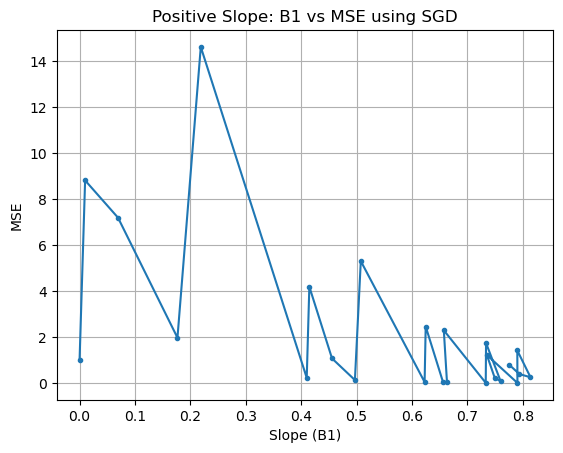

In [17]:
x=np.array([1, 2, 4, 3, 5])
y=np.array([1, 3, 3, 2, 5])

B0=0
B1=0

alpha=0.01

slopes=[]
mse_values=[]

iteration=0

# SGD
for epoch in range(5):

    for i in range(len(x)):

        y_pred=B0+B1*x[i]

        error=y_pred-y[i]

        mse=error**2

        slopes.append(B1)
        mse_values.append(mse)

        B0=B0-alpha*error

        B1=B1-alpha*error*x[i]

        iteration=iteration+1

print("Iterations =", iteration)
print("B0 =", round(B0, 4))
print("B1 =", round(B1, 4))
print("Final Error =", round(mse_values[-1], 4))

plt.figure()

plt.plot(slopes, mse_values, marker="o", markersize=3)

plt.xlabel("Slope (B1)")
plt.ylabel("MSE")
plt.title("Positive Slope: B1 vs MSE using SGD")

plt.grid()
plt.show()

Iterations = 25
B0 = 0.7813
B1 = 0.8372
Final Error = 16.0778


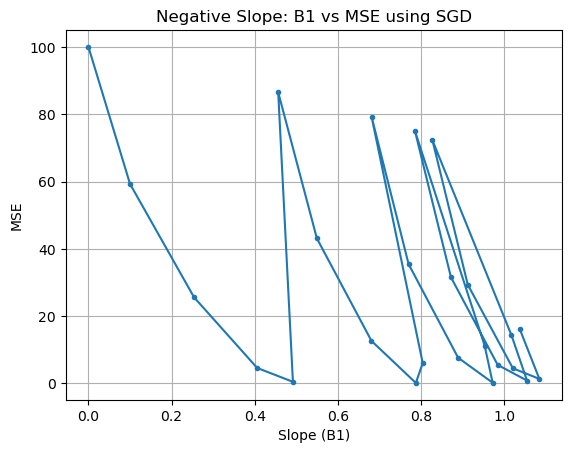

In [18]:
x=np.array([1, 2, 3, 4, 5])
y=np.array([10, 8, 6, 4, 2])

B0=0
B1=0

alpha=0.01

slopes=[]
mse_values=[]

iteration=0

for epoch in range(5):

    for i in range(len(x)):

        y_pred=B0+B1*x[i]

        error=y_pred-y[i]

        mse=error**2

        slopes.append(B1)
        mse_values.append(mse)

        B0=B0-alpha*error
        B1=B1-alpha*error*x[i]
        iteration=iteration + 1

print("Iterations =", iteration)
print("B0 =", round(B0, 4))
print("B1 =", round(B1, 4))
print("Final Error =", round(mse_values[-1], 4))


# Slope vs MSE
plt.figure()

plt.plot(slopes, mse_values, marker="o", markersize=3)

plt.xlabel("Slope (B1)")
plt.ylabel("MSE")
plt.title("Negative Slope: B1 vs MSE using SGD")

plt.grid()
plt.show()

# Q4.

B0 = 0.0105
B1 = 0.1705
Final Log Loss = 0.3769


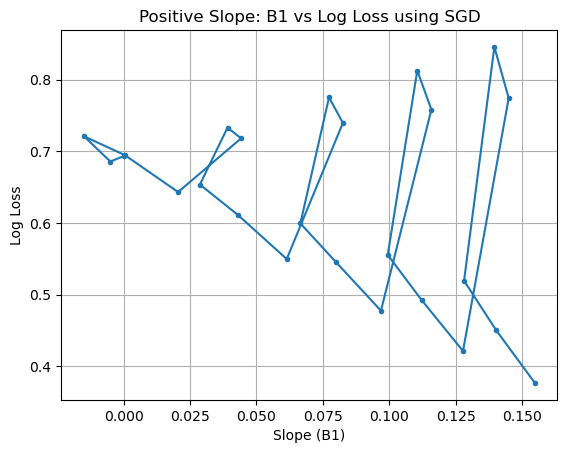

In [20]:
x=np.array([1, 2, 3, 4, 5])
y=np.array([0, 0, 1, 1, 1])

B0=0
B1=0

alpha=0.01
iterations=100

slopes=[]
log_losses = []

n=len(x)

for epoch in range(5):

    for i in range(len(x)):

        z=B0+B1*x[i]

        y_pred=1/(1+np.exp(-z))

        log_loss=-(y[i]*np.log(y_pred)+(1-y[i])*np.log(1-y_pred))

        error=y_pred-y[i]

        slopes.append(B1)
        log_losses.append(log_loss)

        B0=B0-alpha*error
        B1=B1-alpha*error*x[i]


print("B0 =", round(B0, 4))
print("B1 =", round(B1, 4))
print("Final Log Loss =", round(log_losses[-1], 4))



plt.figure()

plt.plot(slopes, log_losses, marker="o", markersize=3)

plt.xlabel("Slope (B1)")
plt.ylabel("Log Loss")
plt.title("Positive Slope: B1 vs Log Loss using SGD")

plt.grid()
plt.show()

B0 = -0.0105
B1 = -0.1705
Final Log Loss = 0.3769


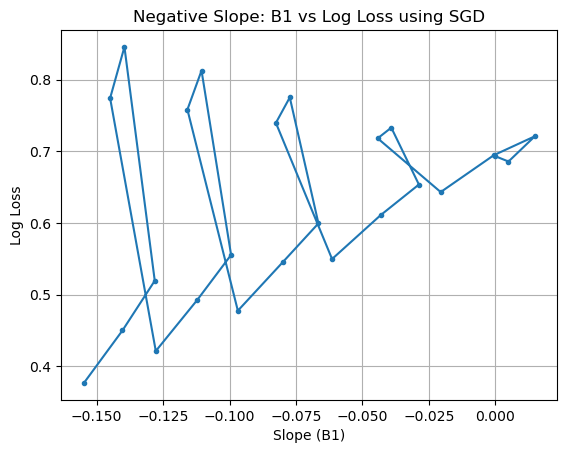

In [22]:
x=np.array([1, 2, 3, 4, 5])
y=np.array([1, 1, 0, 0, 0])

B0=0
B1=0

learning_rate = 0.1
epochs = 20

slopes=[]
log_losses=[]

for epoch in range(5):

    for i in range(len(x)):

        z=B0+B1*x[i]

        y_pred=1/(1+np.exp(-z))


        log_loss=-(y[i]*np.log(y_pred)+(1-y[i])*np.log(1-y_pred))

        error=y_pred-y[i]

        slopes.append(B1)
        log_losses.append(log_loss)

        B0=B0-alpha*error
        B1=B1-alpha*error*x[i]


print("B0 =", round(B0, 4))
print("B1 =", round(B1, 4))
print("Final Log Loss =", round(log_losses[-1], 4))



plt.figure()

plt.plot(slopes, log_losses, marker="o", markersize=3)

plt.xlabel("Slope (B1)")
plt.ylabel("Log Loss")
plt.title("Negative Slope: B1 vs Log Loss using SGD")

plt.grid()
plt.show()
plt.show()

# Q5.

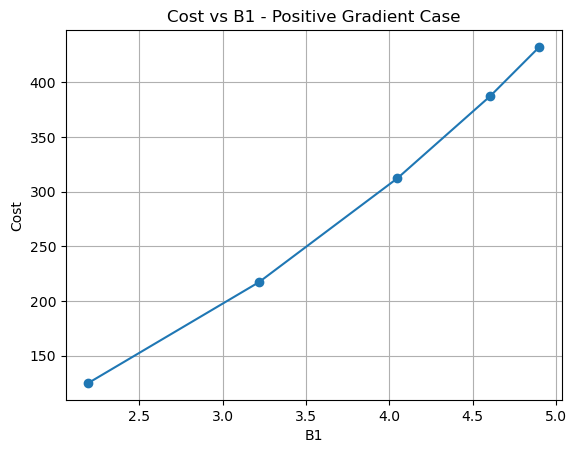

In [36]:
x=np.array([1, 2, 3, 4, 5])
y=np.array([0, 0, 0, 0, 0])

B0=5.0
B1=5.0

alpha=0.01

B1_values=[]
cost_values=[]


for i in range(len(x)):

    y_pred=B0+B1*x[i]
    
    error=y_pred-y[i]

    gradient_B0=error
    gradient_B1=error*x[i]

    B0=B0-alpha*gradient_B0
    B1=B1-alpha*gradient_B1

    all_predictions=B0+B1*x
    cost=np.mean((all_predictions-y)**2)

    B1_values.append(B1)
    cost_values.append(cost)
    
plt.figure()

plt.plot(B1_values, cost_values, marker="o")

plt.xlabel("B1")
plt.ylabel("Cost")
plt.title("Cost vs B1 - Positive Gradient Case")

plt.grid()
plt.show()

# Q6.

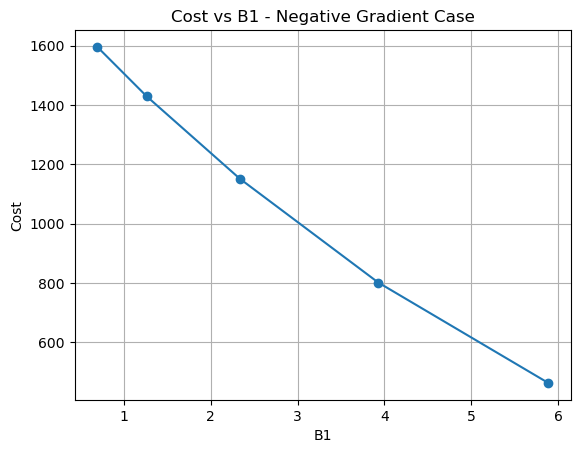

In [37]:
x=np.array([1, 2, 3, 4, 5])
y=np.array([20, 30, 40, 50, 60])

B0=0.0
B1=0.5

alpha=0.01

B1_values=[]
cost_values=[]


for i in range(len(x)):

    y_pred=B0+B1*x[i]
    
    error=y_pred-y[i]

    gradient_B0=error
    gradient_B1=error*x[i]

    B0=B0-alpha*gradient_B0
    B1=B1-alpha*gradient_B1

    all_predictions=B0+B1*x
    cost=np.mean((all_predictions-y)**2)

    B1_values.append(B1)
    cost_values.append(cost)
    
plt.figure()

plt.plot(B1_values, cost_values, marker="o")

plt.xlabel("B1")
plt.ylabel("Cost")
plt.title("Cost vs B1 - Negative Gradient Case")

plt.grid()
plt.show()